In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import os
from random import shuffle

In [2]:
TRAIN_DIR = '/content/train'
TEST_DIR = '/content/test'

In [3]:
IMG_SIZE = 120
MODEL_NAME = 'NIKEvsADIDAS'

In [4]:
def label_image(img):
  word_label = img.split('_')[0]
  if word_label == 'NIKE': return [1,0]
  elif word_label == 'ADIDAS': return [0,1]

In [6]:
train_data = []
for img in tqdm(os.listdir(TRAIN_DIR)):
  label = label_image(img)
  path = os.path.join(TRAIN_DIR,img)

  # PIL
  img = Image.open(path)
  img = img.convert('L')
  img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)
  #Create composite image by blending images using a transparency mask. ..
  # ANTIALIAS (a high-quality downsampling filter).

  train_data.append([np.array(img), np.array(label)])

shuffle(train_data)

100%|██████████| 100/100 [00:00<00:00, 317.66it/s]


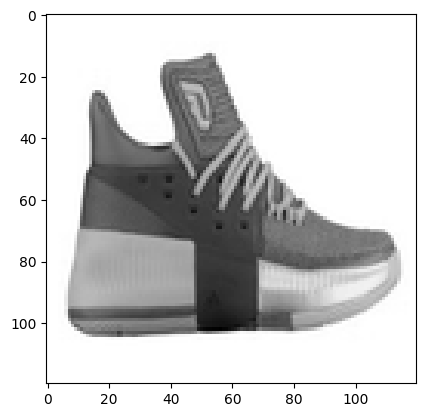

In [7]:
plt.imshow(train_data[35][0], cmap='gist_gray')
plt.show()

In [8]:
import keras
from keras.layers import Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten

In [12]:
model = Sequential()

model.add(Conv2D(32,(5,5), activation='relu', input_shape=(120,120,1)))
model.add(Conv2D(32,(5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(5,5), activation='relu'))
model.add(Conv2D(64,(5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(5,5), activation='relu'))
model.add(Conv2D(64,(5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(2, activation='softmax')) #adidas or nike 2 options so last layer has 2 neurons.

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
x = np.array([i[0] for i in train_data]).reshape(-1,IMG_SIZE,IMG_SIZE,1)
y = np.array([i[1] for i in train_data])

model.fit(x,y,epochs=10)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.5000 - loss: 22.9139
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.5600 - loss: 3.1198
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.5000 - loss: 0.6888
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.5200 - loss: 0.6688
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.6700 - loss: 0.5841
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.8500 - loss: 0.4482
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.7000 - loss: 0.8686
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8300 - loss: 0.4608
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.8300 - loss: 0.4751
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8200 - loss: 0.4349


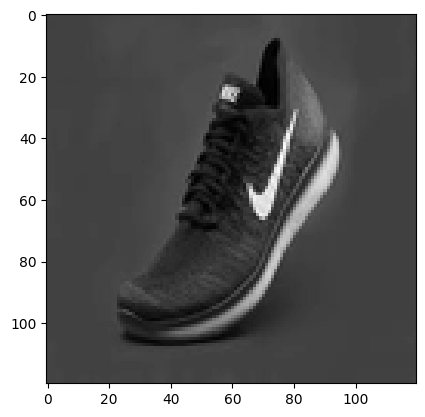

In [19]:
# PIL
img = Image.open('/content/niketest.jpg')
img = img.convert('L')
img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)

plt.imshow(np.array(img), cmap='gist_gray')
plt.show()

In [20]:
model.predict(np.array(img).reshape(-1,IMG_SIZE,IMG_SIZE,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([[0.50971603, 0.49028394]], dtype=float32)

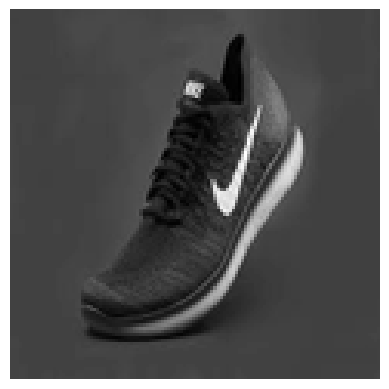

Raw Prediction: [[0.50971603 0.49028394]]
Predicted: NIKE 👟


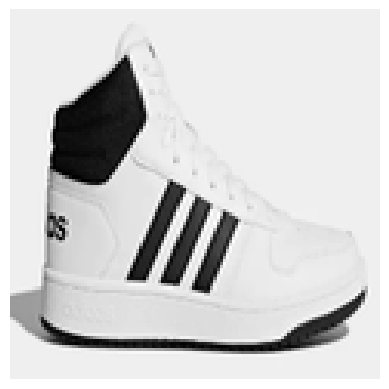

Raw Prediction: [[0.00995868 0.9900413 ]]
Predicted: ADIDAS 👟


In [21]:
def predict_shoe(image_path):
    img = Image.open(image_path)
    img = img.convert('L')
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)

    plt.imshow(np.array(img), cmap='gist_gray')
    plt.axis("off")
    plt.show()

    pred = model.predict(np.array(img).reshape(-1, IMG_SIZE, IMG_SIZE, 1), verbose=0)
    print("Raw Prediction:", pred)

    if pred[0][0] > pred[0][1]:
        print("Predicted: NIKE 👟")
    else:
        print("Predicted: ADIDAS 👟")
predict_shoe("//content/niketest.jpg")
predict_shoe("/content/adidas1.png")

In [22]:
model.save("nike_adidas_classifier.keras")

In [23]:
from google.colab import files
files.download("nike_adidas_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>